In [1]:
import os
print("Working directory:", os.getcwd())
print("Conda environment:", os.environ.get('CONDA_DEFAULT_ENV'))

Working directory: /shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/wnw/notebooks
Conda environment: wnw


In [2]:
import os, bz2
from collections import Counter
import pandas as pd
from glob import iglob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings 
from statannotations.Annotator import Annotator
from multiprocessing import Event, Pool
from scipy.stats import spearmanr, linregress
import statistics
warnings.filterwarnings("ignore")
plt.rcParams['svg.fonttype'] = 'none'

### **Paths**

In [3]:
basedir = '/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/'
metaref = '/shares/CIBIO-Storage/CM/scratch/databases/MetaRefSGB/releases/Jan21/SGB.Jan21.txt.bz2'

### **SGB selection**
Only use SGBs with a prevalence of at least 0.05

In [4]:
metadata = pd.read_csv(os.path.join(basedir,'nw_metadata.tsv'), sep='\t')
metadata.index = metadata['sample_id']

to_profile_sgbs = dict()
with open(os.path.join(basedir,'strainphlan','print_clades_only.txt'), 'r') as read_file:
    for line in read_file:
        if 't__SGB' in line:
            sgb = line.strip().split('t__')[1].split(':')[0]
            samples = line.strip().split('[')[1].split(']')[0].replace("'",'').split(', ')
            nw = 0
            w = 0
            for sample in samples:
                if metadata.loc[sample]['non_westernized'] == 'yes':
                    nw += 1
                elif metadata.loc[sample]['non_westernized'] == 'no':
                    w += 1
            to_profile_sgbs[sgb] = [w,nw]
print('Number of SGBs before filtering:', len(to_profile_sgbs))
prevalence_threshold = 0.05
meta_yes =  len(metadata[metadata['non_westernized'] == 'yes'])
meta_no =  len(metadata[metadata['non_westernized'] == 'no'])
selected_sgbs = list()
for sgb in to_profile_sgbs:
    w,nw = to_profile_sgbs[sgb]
    if nw/meta_yes >= prevalence_threshold and w/meta_no >= prevalence_threshold:
        selected_sgbs.append(sgb)
print('Number of SGBs after filtering:', len(selected_sgbs))

Number of SGBs before filtering: 2139
Number of SGBs after filtering: 124


### **Get anpan results**

In [5]:
results = list()

for output in iglob(
    os.path.join(
        basedir,
        'scripts',
        'anpan',
        'SGB*.o'
        )
    ):
    if 'nocountry' not in output:
        with open(output) as rf:
            sgb = output.split('/')[-1][:-2]
            higher, diff, sd, good, ok, bad, verybad, bad_perc = pd.NA, pd.NA, pd.NA, pd.NA, pd.NA, pd.NA, pd.NA, pd.NA 
            for line in rf:
                if line.strip().startswith('Pareto k diagnostic values'):
                    rf.readline()
                    good = int(rf.readline().split('(good)')[1].strip().split(' ')[0])
                    ok = int(rf.readline().split('(ok)')[1].strip().split(' ')[0])
                    bad =int(rf.readline().split('(bad)')[1].strip().split(' ')[0])
                    verybad = int(rf.readline().split('(very bad)')[1].strip().split(' ')[0])
#                     print(good, ok, bad, verybad)
                    bad_perc = ((bad + verybad) / (good + ok + bad + verybad )) * 100
                    
                    break
                elif line.strip().startswith('elpd_diff'):
                    first = rf.readline().strip()
                    second = rf.readline().strip()
                    if '-' in second:
                        diff = -float(second.split('-')[1].split(' ')[0])
                    else:
                        diff = 0.0                     
                    sd = float(second.split(' ')[-1])
                    diffse = 2*sd + diff
                    if first.startswith('pglmm_fit'):
                        higher = 'phylo'        
                    else:   
                        higher = 'base'      
            results.append([sgb, higher, diff, sd, diffse, good, ok, bad, verybad, bad_perc])  
df = pd.DataFrame(results)
df.columns = ['SGBID', 'BestModel', 'DiffModels', 'SE', 'DiffSE', 'Good', 'Ok', 'Bad', 'VeryBad', 'PercBad']
df.index = df.SGBID
df = df.drop('SGBID', axis=1)
df = df.sort_values(['DiffModels'])


In [8]:
# Parse out selected SGBs
df = df.loc[[x for x in selected_sgbs]]

# Get effect size relative to 'phylo' model
df['DiffModels_relative'] = df['DiffModels']
df.loc[df['BestModel'] == 'phylo', 'DiffModels_relative'] *= -1

# Get significant SGBs
phylo = df[df['BestModel'] == 'phylo']

sig_phylo = phylo[
    (phylo['DiffModels'] < -4) &
    (phylo['DiffSE'] < 0) &
    (phylo['PercBad'] <= 5)
]
sig_phylo.head()

,BestModel,DiffModels,SE,DiffSE,Good,Ok,Bad,VeryBad,PercBad,DiffModels_relative
SGBID,,,,,,,,,,
SGB4933_group,phylo,-864.4,287.1,-290.2,7288,57,26,28,0.729828,864.4
SGB4837_group,phylo,-747.7,300.8,-146.1,6769,13,7,14,0.308687,747.7
SGB15342,phylo,-85.3,28.8,-27.7,5391,15,7,6,0.239897,85.3
SGB4925,phylo,-1444.6,470.5,-503.6,5205,12,2,3,0.095749,1444.6
SGB4285_group,phylo,-643.9,277.2,-89.5,5022,38,12,28,0.784314,643.9


In [15]:
sig_phylo.to_csv("../revision/anpan_significant.tsv", sep="\t")

In [9]:
significant_sgbs = sig_phylo.index.tolist()

In [10]:
merged_sgbs = []
groups = []
with open(
    '/shares/CIBIO-Storage/CM/scratch/databases/chocophlansgb/releases/Jan21/Jan21_merged_sgbs.csv', 'r'
    ) as read_file:
    read_file.readline()
    for line in read_file:
        line = line.strip().split(';')
        groups.append(line)
        merged_sgbs.append([line[0][3:]] + line[1].split(','))  

### **Transmission**
#### SGB transmission rates
Obtained from Valles-Colomer et al. (2023)

In [12]:
transmission = pd.read_csv('../data/transmission_rates_sgb.tsv', sep='\t', index_col=[0])
transmission.head()

,SGB_mother-infant_transmissibility,SGB_household_transmissibility,SGB_intradataset_transmissibility
SGB,,,
SGB10068,0.44375,0.148476,0.111870
SGB10115_group,NaN,0.349183,0.275790
SGB10130,NaN,0.130952,0.045643
SGB10131,NaN,0.112676,0.056301
SGB10139_group,NaN,0.127660,0.085865


### **Get transmission values for selected SGBs**

In [14]:
done = transmission.index.tolist()
sgb2transmission = {}
match_sgbs = {}
for i_sgb in selected_sgbs:
    sgb_id = i_sgb.replace('SGB','').replace('_group','').replace('15317','15316').replace('8007', '8002')
    found = False
    sgbs = [sgb_id]
    for merge in merged_sgbs:
        if sgb_id in merge:
            sgbs = merge
    found = False
    for sgb in sgbs:        
        if 'SGB' + sgb in done:
            sgb2transmission[i_sgb] = transmission.loc['SGB' + sgb]
            match_sgbs[i_sgb] = sgb
            found = True
            break
        elif 'SGB' + sgb.split('_')[0] in done:
            sgb2transmission[i_sgb] = transmission.loc['SGB' + sgb.split('_')[0]]
            match_sgbs[i_sgb] = sgb
            found = True
            break
        elif 'SGB' + sgb + '_group' in done:
            found = True
            sgb2transmission[i_sgb] = transmission.loc['SGB' + sgb + '_group']
            match_sgbs[i_sgb] = sgb
            break
    if not found:
        print(i_sgb)
sgb2transmission = pd.DataFrame(sgb2transmission)

SGB4837_group
SGB14546_group
SGB4563_group
SGB1871
SGB4262
SGB15368
SGB15053_group
SGB5765_group
SGB8071


### **Match SGB ids with taxonomies**
Taxonomy annotations obtained from Table S4 in [transmission paper](https://www.nature.com/articles/s41586-022-05620-1).

In [15]:
from collections import defaultdict

match_sgbs = {}
for i_sgb in selected_sgbs:
    sgb_id = i_sgb.replace('SGB','').replace('_group','').replace('15317','15316').replace('8007', '8002')
    found = False
    sgbs = [sgb_id]
    for merge in merged_sgbs:
        if sgb_id in merge:
            sgbs = merge
    found = False
    for sgb in sgbs:        
        if 'SGB' + sgb in done:
            match_sgbs[i_sgb] = sgbs
            found = True
            break
        elif 'SGB' + sgb.split('_')[0] in done:
            match_sgbs[i_sgb] = sgbs
            found = True
            break
        elif 'SGB' + sgb + '_group' in done:
            found = True
            match_sgbs[i_sgb] = sgbs
            break
    if not found:
        print(i_sgb)

flipped = defaultdict(list)
for key, value in match_sgbs.items():
    flipped[tuple(value)].append(key)

flipped = dict(flipped)

mireia_taxonomy = pd.read_csv('/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/wnw/data/transmission_taxonomy.csv')
sgb2taxonomy = dict(zip(mireia_taxonomy.SGB, mireia_taxonomy.Taxonomy))

taxo = {}
for i in sgb2taxonomy:
    for j in flipped:
        if i[3:].split('_')[0] in j:
            taxo[tuple(flipped[j])] = sgb2taxonomy[i]

taxonomy_final = {}
for i in taxo:
    for j in i:
        taxonomy_final[j] = taxo[i]

for tax in taxonomy_final:
    multitax = taxonomy_final[tax].split(';')
    if len(multitax) > 1:
        if 'group' not in tax:
            match = False
            nid = tax[3:]
            for x in multitax:
                if nid in x:
                    match = True
                    print(tax, x)
            if not match:
                print('X',nid)

SGB4837_group
SGB14546_group
SGB4563_group
SGB1871
SGB4262
SGB15368
SGB15053_group
SGB5765_group
SGB8071
SGB4938 k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Lachnospiraceae|g__Roseburia|s__Roseburia_sp_AF02_12|t__SGB4938
SGB15234 k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Ruminococcaceae|g__GGB9708|s__GGB9708_SGB15234|t__SGB15234
SGB15031 k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Ruminococcaceae|g__GGB9602|s__GGB9602_SGB15031|t__SGB15031


### **Get list of food-derived SGBs**
From [transmission paper](https://www.nature.com/articles/s41586-022-05620-1) -- supplementary table S6.


In [16]:
food_sgbs = [
    "SGB7088",
    "SGB7144",
    "SGB8002_group",
    "SGB10068",
    "SGB17247",
    "SGB17248",
    "SGB10115_group",
    "SGB17278",
    "SGB17248",
    "SGB8002_group"
]

is_food_sgb = []
for sgb in food_sgbs:
    for merge_sgb in flipped:
        if sgb[3:].split('_')[0] in merge_sgb:
            # print(sgb, flipped[merge_sgb])
            is_food_sgb.append(flipped[merge_sgb])

def flatten(list_of_lists):
    return [item for sublist in list_of_lists for item in sublist]

def unique(duplicate_list):
    return list(set(duplicate_list))

food_sgb_list = unique(flatten(is_food_sgb))

### **Prepare results for plotting**

In [17]:
df['sig'] = (df['BestModel'] == 'phylo') & (df['DiffModels'] < -4) & (df['DiffSE'] < 0) & (df['PercBad'] <= 5)

In [18]:
df_anpan_trans_mireia = sgb2transmission.T.merge(df, left_index=True, right_index=True)
df_anpan_trans_mireia['DiffModels'] = pd.to_numeric(df_anpan_trans_mireia['DiffModels'], errors='coerce')
df_anpan_trans_mireia['DiffModels_relative'] = pd.to_numeric(df_anpan_trans_mireia['DiffModels_relative'], errors='coerce')
df_anpan_trans_mireia.head(5)

,SGB_mother-infant_transmissibility,SGB_household_transmissibility,SGB_intradataset_transmissibility,BestModel,DiffModels,SE,DiffSE,Good,Ok,Bad,VeryBad,PercBad,DiffModels_relative,sig
SGB4933_group,0.280000,0.105033,0.019616,phylo,-864.4,287.1,-290.2,7288,57,26,28,0.729828,864.4,True
SGB1836_group,0.729323,0.196581,0.023868,phylo,-89.7,87.7,85.7,7316,10,16,27,0.583526,89.7,False
SGB1814,0.697479,0.242105,0.076939,base,-0.4,0.8,1.2,6918,29,8,2,0.14374,-0.4,False
SGB4874,0.250000,0.078795,0.021058,phylo,-21.3,21.5,21.7,5991,8,14,16,0.497595,21.3,False
SGB15316_group,0.103448,NaN,NaN,base,-0.4,1.2,2.0,5738,3,0,0,0.0,-0.4,False


Text(0, 0.5, 'anpan phylo model effect size')

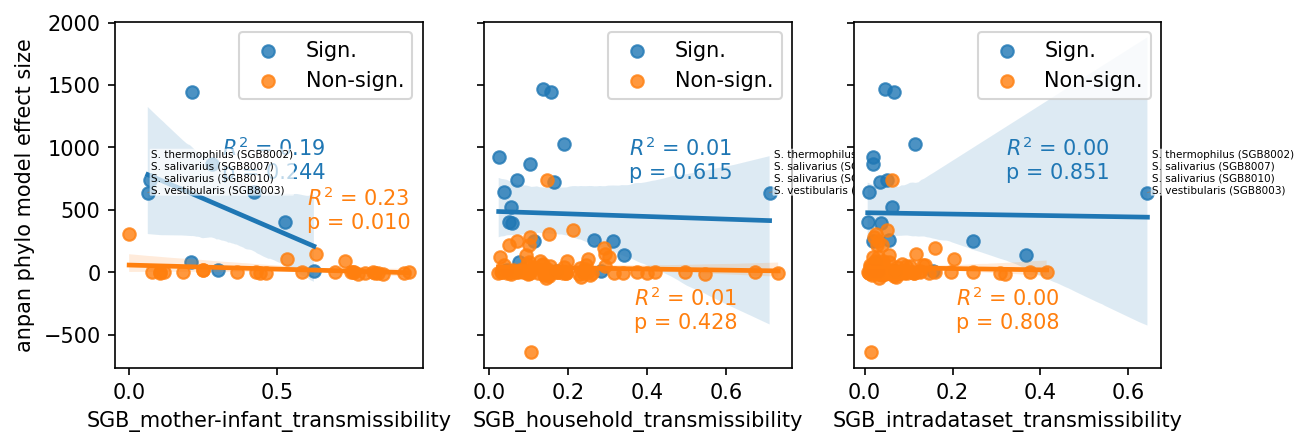

In [19]:
fig, ax = plt.subplots(dpi=150, figsize=(9,3), ncols=3, sharey=True)

# Transmission scenarios
tm_cols = df_anpan_trans_mireia.columns[:3]

for n, col in enumerate(tm_cols):
    
    sns.regplot(
        data = df_anpan_trans_mireia[df_anpan_trans_mireia['sig']==True],
        x = col,
        y = 'DiffModels_relative',
        label = 'Sign.',
        ax = ax[n]
    )
    
    sns.regplot(
        data = df_anpan_trans_mireia[df_anpan_trans_mireia['sig']==False],
        x = col,
        y = 'DiffModels_relative',
        label = 'Non-sign.',
        ax = ax[n]
    )

    # Linear regression
    xval = df_anpan_trans_mireia[df_anpan_trans_mireia['sig']==True][col]
    yval = df_anpan_trans_mireia[df_anpan_trans_mireia['sig']==True]['DiffModels_relative']
    valid = xval.notna() & yval.notna()
    xval_clean = xval[valid]
    yval_clean = yval[valid]
    slope, intercept, r_value, p_value, std_err = linregress(
        xval_clean, yval_clean
        )
    tmmax = xval.max()
    r, p = spearmanr(xval_clean, yval_clean)
    ax[n].text(tmmax/2, 750, f"$R^2$ = {r**2:.2f}\np = {p:.3f}", c='tab:blue')

    xval = df_anpan_trans_mireia[df_anpan_trans_mireia['sig']==False][col]
    yval = df_anpan_trans_mireia[df_anpan_trans_mireia['sig']==False]['DiffModels_relative']
    valid = xval.notna() & yval.notna()
    xval_clean = xval[valid]
    yval_clean = yval[valid]
    slope, intercept, r_value, p_value, std_err = linregress(
        xval_clean, yval_clean
        )
    tmmax = xval.max()
    r, p = spearmanr(xval_clean, yval_clean)
    if n == 0:
        ax[n].text(.6, 350, f"$R^2$ = {r**2:.2f}\np = {p:.3f}", c='tab:orange')
    else:
        ax[n].text(tmmax/2, -450, f"$R^2$ = {r**2:.2f}\np = {p:.3f}", c='tab:orange')
    
    ax[n].set_ylabel('')
    ax[n].legend()


for n, col in enumerate(tm_cols):
    sub = df_anpan_trans_mireia[df_anpan_trans_mireia['sig']==True]
    food_selected = sub.loc[set(sub.index).intersection(set(food_sgb_list))]
    for _, i in food_selected.iterrows():
        # Format taxonomic name
        taxid = [' ('.join(j.split('s__')[-1].split('|t__')) + ')' for j in taxonomy_final[i.name].split(';')]
        abr_taxids = []
        for sp in taxid:
            genus, species = sp.split('_')
            abr_taxids.append('. '.join([genus[0], species]))
        taxannot = '\n'.join(abr_taxids)

        x = i[col]
        y = i['DiffModels_relative']
        
        # Offset for annotation to avoid overlap
        offset_x = 0.01  # adjust based on your scale
        offset_y = 0.01

        # Annotate with arrow (leader line)
        ax[n].annotate(
            taxannot,
            xy=(x, y),  # point to annotate
            xytext=(x + offset_x, y + offset_y),  # position of text
            textcoords='data',
            arrowprops=dict(arrowstyle='-', lw=0.5, color='gray'),
            fontsize=5,
            zorder=10,
            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.7)
        )


ax[0].set_ylabel('anpan phylo model effect size')

# fig.text(0, 0.55, 'anpan phylo model effect size', va='center', rotation='vertical')
# fig.tight_layout()
# fig.savefig('../anpan_vs_sergiotrans.png', format='png', dpi=500)
# fig.savefig('../anpan_vs_sergiotrans.pdf', format='pdf', dpi=500)

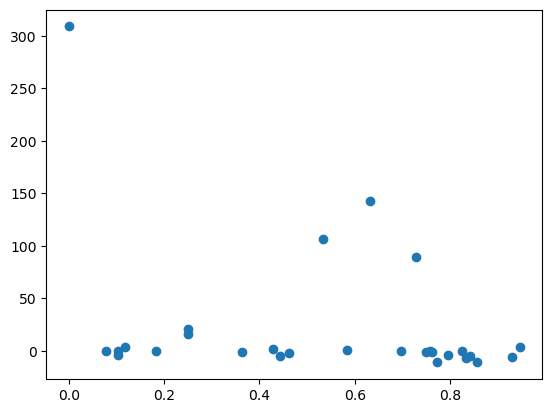

In [20]:
plt.scatter(
    df_anpan_trans_mireia[df_anpan_trans_mireia["sig"]==False]["SGB_mother-infant_transmissibility"],
    df_anpan_trans_mireia[df_anpan_trans_mireia["sig"]==False]['DiffModels_relative']
)

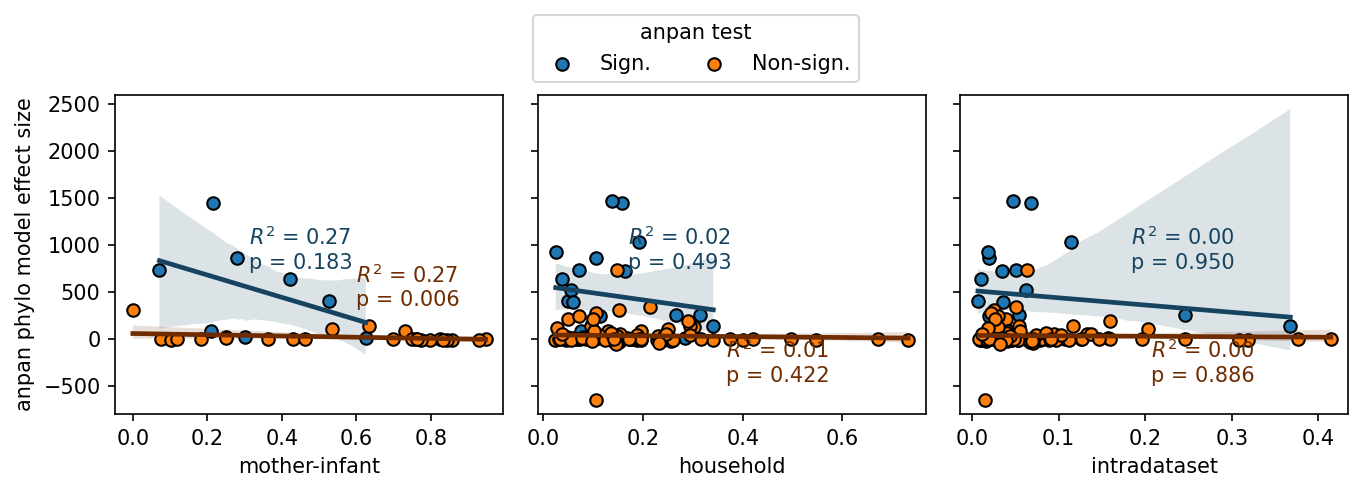

In [22]:
fig, ax = plt.subplots(dpi=150, figsize=(9,3), ncols=3, sharey=True)

# Transmission scenarios
is_food_sgb = df_anpan_trans_mireia.index.isin(food_sgb_list)
df_anpan_trans_filtered = df_anpan_trans_mireia.loc[~is_food_sgb]
tm_cols = df_anpan_trans_filtered.columns[:3]

for n, col in enumerate(tm_cols):

    sub_true = df_anpan_trans_filtered[df_anpan_trans_filtered['sig']==True]
    sub_false = df_anpan_trans_filtered[df_anpan_trans_filtered['sig']==False]
    
    sns.regplot(
        data = sub_true,
        x = col,
        y = 'DiffModels_relative',
        ax = ax[n],
        scatter = False,
        color = "#154360"
    )
    
    sns.regplot(
        data = sub_false,
        x = col,
        y = 'DiffModels_relative',
        ax = ax[n],
        scatter = False,
        color = "#6e2c00"
    )

    ax[n].scatter(
        x = sub_true[col],
        y = sub_true['DiffModels_relative'],
        edgecolor = 'k',
        label = 'Sign.',
    )

    ax[n].scatter(
        x = sub_false[col],
        y = sub_false['DiffModels_relative'],
        edgecolor = 'k',
        label = 'Non-sign.',
    )

    # Linear regression
    colselect = [col,'DiffModels_relative']
    notna = sub_true[colselect].dropna()
    xval = notna[col].values
    yval = notna['DiffModels_relative'].values
    tmmax = xval.max()
    r, p = spearmanr(xval, yval)
    ax[n].text(tmmax/2, 750, f"$R^2$ = {r**2:.2f}\np = {p:.3f}", c='#154360')

    notna = sub_false[colselect].dropna()
    xval = notna[col].values
    yval = notna['DiffModels_relative'].values
    tmmax = xval.max()
    r, p = spearmanr(xval, yval)
    if n == 0:
        ax[n].text(.6, 350, f"$R^2$ = {r**2:.2f}\np = {p:.3f}", c='#6e2c00')
    else:
        ax[n].text(tmmax/2, -450, f"$R^2$ = {r**2:.2f}\np = {p:.3f}", c='#6e2c00')
    
    ax[n].set_ylabel('')
    ax[n].set_xlabel(col.split('_')[1])
    
# Create a combined legend from one of the axes (e.g., ax[0])
handles, labels = ax[0].get_legend_handles_labels()

# Place the legend above all subplots
fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 1.1),  # Adjust vertical spacing as needed
    title='anpan test'
)

# Adjust layout to make space for the legend
fig.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space at the top for the legend
ax[0].set_ylabel('anpan phylo model effect size')

# fig.text(0, 0.55, 'anpan phylo model effect size', va='center', rotation='vertical')
# fig.tight_layout()
fig.savefig('../anpan_vs_mireia_filtered.png', format='png', dpi=500)
fig.savefig('../anpan_vs_mireia_filtered.pdf', format='pdf', dpi=500)
fig.savefig('../anpan_vs_mireia_filtered.svg', format='svg')